# Proyecto 1 
Integrantes:
- Diego Céspedes
- Carlos Méndez
- Simon Fajardo
- Diego Sarmiento

In [1]:
print("hello world")

hello world


## Importar dataset

In [ ]:
#Es necesario que esté el % en el pip para que la libreria se instale correctamente en el entorno del notebook

%pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features  ## data para predecir
y = predict_students_dropout_and_academic_success.data.targets   ## variable objetivo a predecir
  
# metadata 
print(predict_students_dropout_and_academic_success.metadata) 
  
# variable information 
print(predict_students_dropout_and_academic_success.variables) 


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

## 1. Análisis Exploratorio y de Dimensionalidad 

--- Información de las Variables Predictoras (X) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   i

None


--- Conteo de Valores Nulos ---
No hay valores nulos en X.

--- Estadísticas Descriptivas de X ---


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


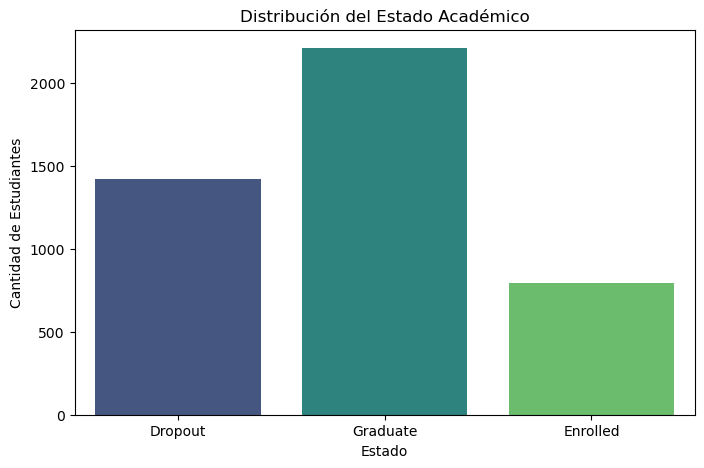


--- Frecuencia de las Clases en y ---
Target  
Graduate    2209
Dropout     1421
Enrolled     794
dtype: int64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Información general y revisión de valores nulos
print("--- Información de las Variables Predictoras (X) ---")
display(X.info())

print("\n--- Conteo de Valores Nulos ---")
nulos = X.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos en X.")

# 2. Estadísticas descriptivas
print("\n--- Estadísticas Descriptivas de X ---")
display(X.describe())

# 3. Distribución de la variable objetivo (y)
# Asumiendo que la columna en y se llama 'Target'
plt.figure(figsize=(8, 5))
sns.countplot(data=y, x='Target', palette='viridis')
plt.title('Distribución del Estado Académico')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Estudiantes')
plt.show()

print("\n--- Frecuencia de las Clases en y ---")
print(y.value_counts())

## 2. Ejecutar selección de variables argumentada mediante filtros estadísticos

(matrices de 
correlación), regularización L1 (Lasso) o extracción de importancia (Feature Importances) 
a partir de un modelo base. 

##### Matriz de Correlación

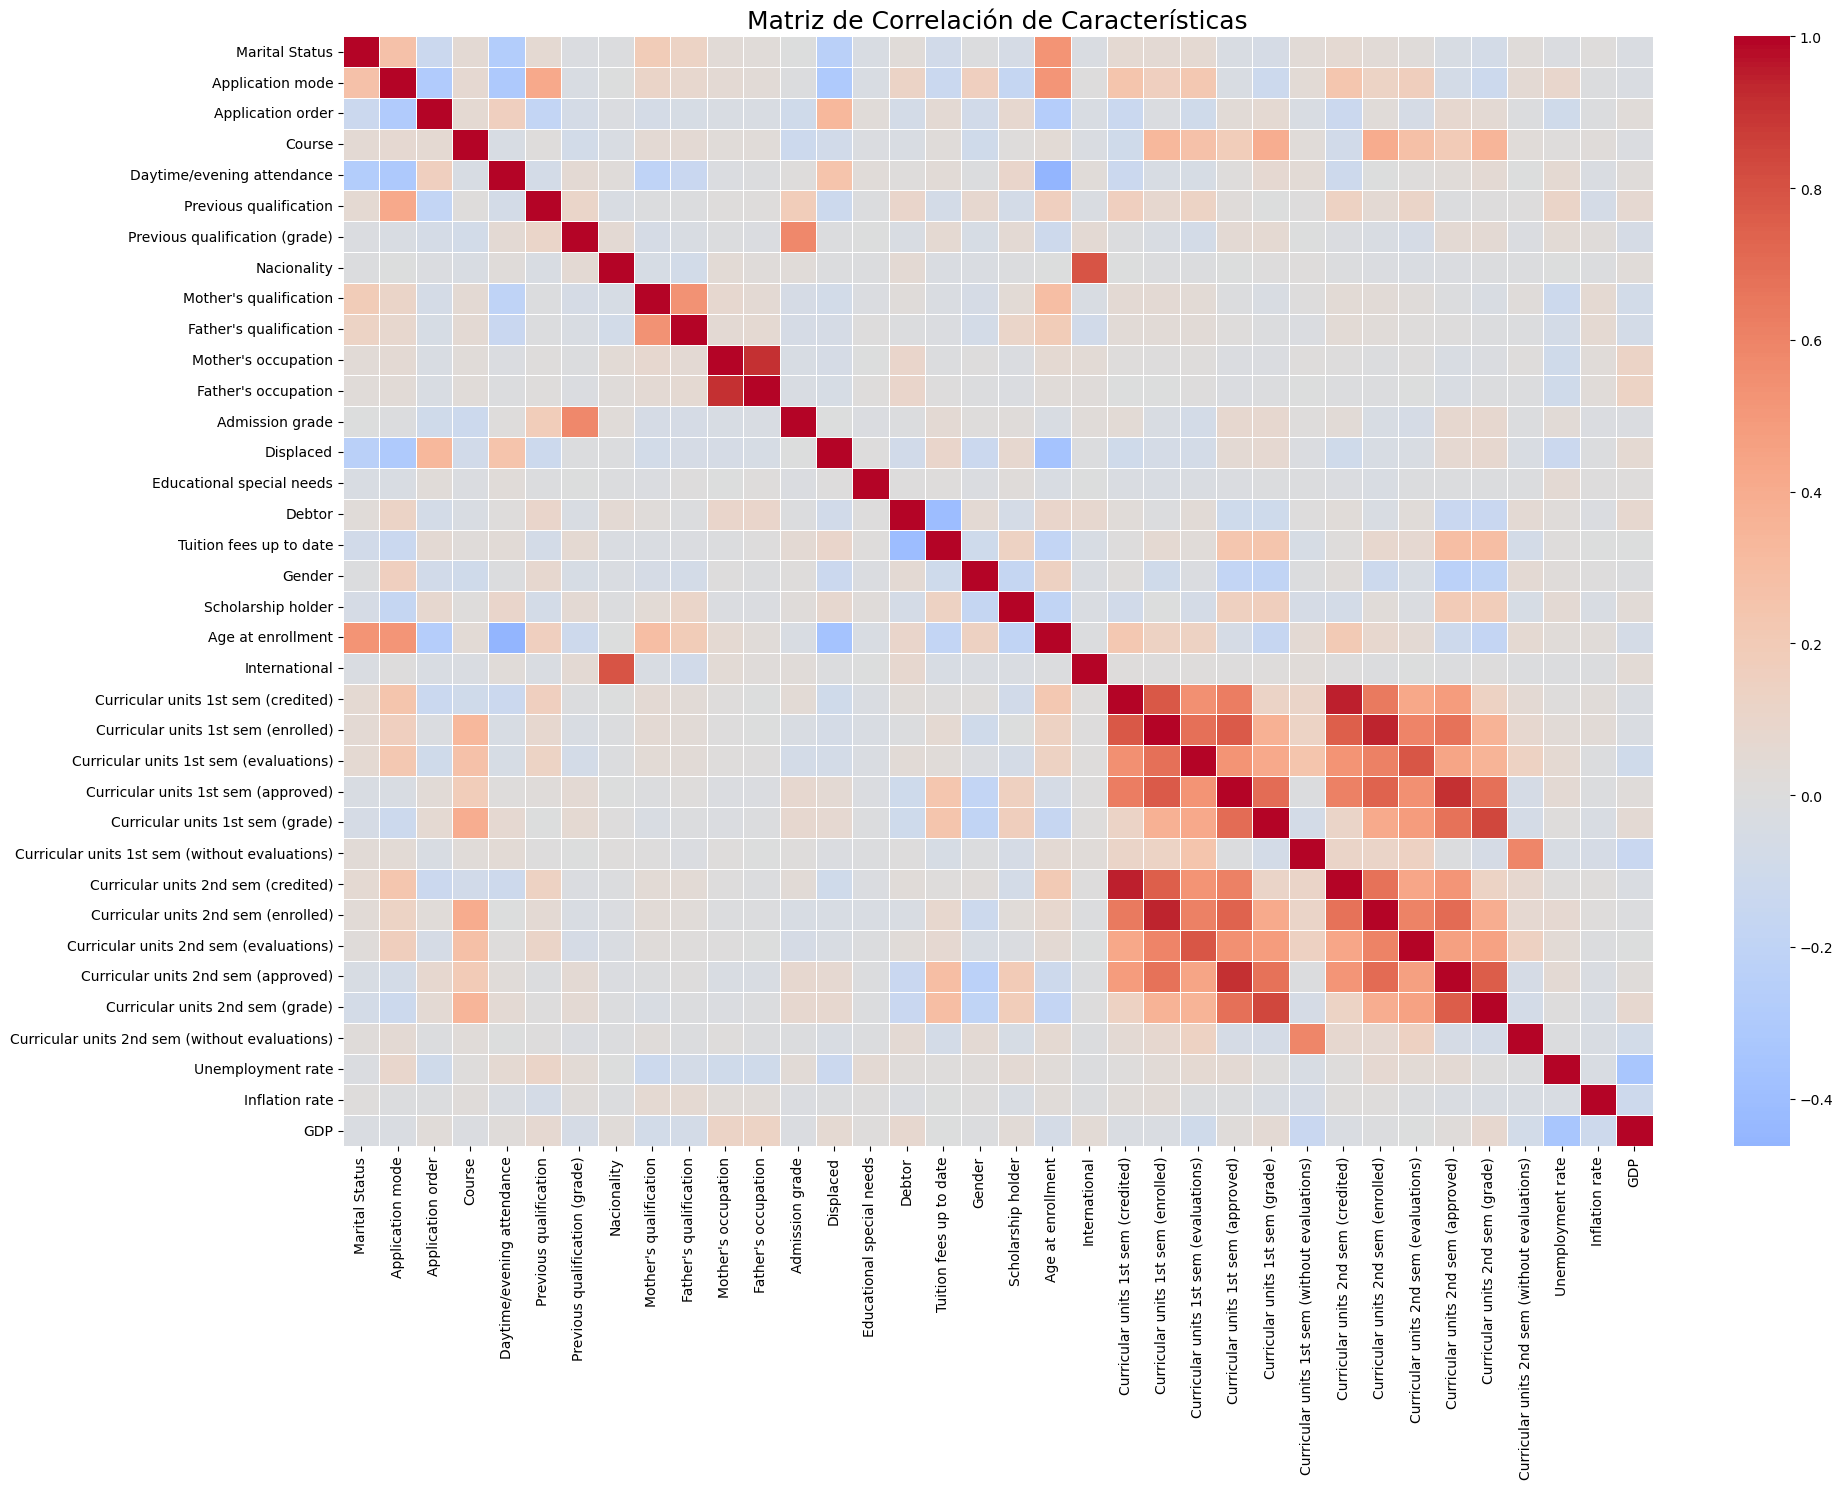


--- Pares de variables con correlación absoluta mayor a 0.8 ---
Curricular units 1st sem (credited)  Curricular units 2nd sem (credited)    0.944811
Curricular units 1st sem (enrolled)  Curricular units 2nd sem (enrolled)    0.942627
Father's occupation                  Mother's occupation                    0.910472
Curricular units 1st sem (approved)  Curricular units 2nd sem (approved)    0.904002
Curricular units 2nd sem (grade)     Curricular units 1st sem (grade)       0.837170
dtype: float64


In [7]:
import numpy as np

# 1. Calcular la matriz de correlación (por defecto usa Pearson)
correlation_matrix = X.corr()

# 2. Visualización con mapa de calor (Heatmap)
plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix, 
    annot=False,      # Mantenemos 'False' para que no se superpongan los números
    cmap='coolwarm',  # Tonos fríos para correlación negativa, cálidos para positiva
    linewidths=0.5,
    center=0
)
plt.title('Matriz de Correlación de Características', fontsize=18)
plt.tight_layout()
plt.show()

# 3. Extracción de variables con alta multicolinealidad (Filtro estadístico)
umbral = 0.8  # Puedes ajustar este valor entre 0.7 y 0.9 según tu criterio
matriz_absoluta = correlation_matrix.abs()

# Desenrollar la matriz para facilitar la lectura de los pares
pares_correlacionados = matriz_absoluta.unstack().sort_values(ascending=False)

# Filtrar las auto-correlaciones (diagonal de 1.0) y aplicar el umbral
pares_filtrados = pares_correlacionados[(pares_correlacionados > umbral) & (pares_correlacionados < 1.0)]

print(f"\n--- Pares de variables con correlación absoluta mayor a {umbral} ---")
# Usamos drop_duplicates() porque la matriz es simétrica (A vs B es lo mismo que B vs A)
print(pares_filtrados.drop_duplicates())

##### Eliminación de Variables redundantes y filtro de clase intermedia
Se eliminan las variables de primer semestre por que el segundo semestre tiene una relación más inmediata con la actualidad

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Filtrar la clase 'Enrolled' y binarizar el Target
# Asumiendo que el target se llama 'Target' (ajusta el nombre si es distinto)
mask = y['Target'] != 'Enrolled'
X_filtrado = X[mask].copy()
y_filtrado = y[mask]['Target'].map({'Dropout': 0, 'Graduate': 1}) # Binarizamos: 0 = Dropout, 1 = Graduate

# 2. Eliminar una variable de cada par altamente correlacionado
columnas_a_eliminar = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    "Father's occupation" # Altamente correlacionado con Mother's occupation
]
X_sin_colinealidad = X_filtrado.drop(columns=columnas_a_eliminar)

# 3. Estandarizar los datos (Lasso es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sin_colinealidad)

# 4. Ajustar modelo con Regularización L1
# solver='liblinear' es necesario para L1 en sklearn
modelo_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.1)
modelo_l1.fit(X_scaled, y_filtrado)

# 5. Visualizar los coeficientes resultantes
coeficientes = pd.Series(modelo_l1.coef_[0], index=X_sin_colinealidad.columns)
coeficientes_ordenados = coeficientes.abs().sort_values(ascending=False)

print("--- Importancia de Variables (Coeficientes L1) ---")
print(coeficientes_ordenados)

variables_descartadas = coeficientes_ordenados[coeficientes_ordenados == 0].index.tolist()
print(f"\nVariables con coeficiente 0 (puedes descartarlas): {variables_descartadas}")

--- Importancia de Variables (Coeficientes L1) ---
Curricular units 2nd sem (approved)               3.414153
Curricular units 2nd sem (enrolled)               1.365867
Tuition fees up to date                           0.793841
Curricular units 2nd sem (grade)                  0.512265
Curricular units 2nd sem (credited)               0.447752
Scholarship holder                                0.348941
Debtor                                            0.326006
Course                                            0.310002
International                                     0.199548
Gender                                            0.172081
Curricular units 1st sem (evaluations)            0.159694
Application mode                                  0.142455
Nacionality                                       0.137978
Mother's occupation                               0.127064
Age at enrollment                                 0.105824
Previous qualification                            0.098266
Displ

In [9]:
# Quitar las variables con coeficiente 0 para obtener el conjunto final de características
X_final = X_sin_colinealidad.drop(columns=variables_descartadas)